In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('precos_carros_brasil.csv')

df.head()

C:\Users\Amanda Neumann\AppData\Local\Temp\ipykernel_2604\2515178643.py:5: DtypeWarning: Columns (0: month_of_reference, 1: fipe_code, 2: authentication, 3: brand, 4: model, 5: fuel, 6: gear, 7: engine_size) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('precos_carros_brasil.csv')


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002.0,9162.0
1,2021.0,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001.0,8832.0
2,2021.0,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000.0,8388.0
3,2021.0,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000.0,8453.0
4,2021.0,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001.0,12525.0


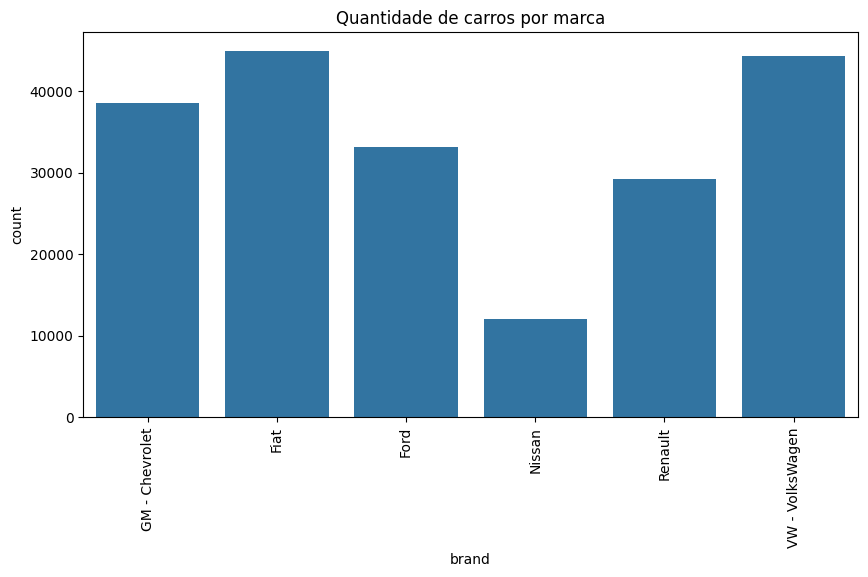

In [3]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='brand')
plt.xticks(rotation=90)
plt.title('Quantidade de carros por marca')
plt.show()

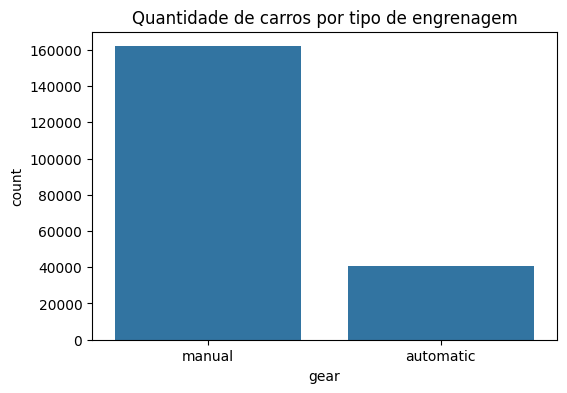

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gear')
plt.title('Quantidade de carros por tipo de engrenagem')
plt.show()

In [11]:
df_tempo = df[['year_of_reference', 'month_of_reference', 'avg_price_brl']].copy()

df_tempo['year_of_reference'] = pd.to_numeric(df_tempo['year_of_reference'], errors='coerce')
df_tempo['month_of_reference'] = pd.to_numeric(df_tempo['month_of_reference'], errors='coerce')

df_tempo = df_tempo.dropna(subset=['year_of_reference', 'month_of_reference', 'avg_price_brl'])

df_tempo['year_of_reference'] = df_tempo['year_of_reference'].astype(int)
df_tempo['month_of_reference'] = df_tempo['month_of_reference'].astype(int)

df_tempo.head()

,year_of_reference,month_of_reference,avg_price_brl


In [13]:
media_preco = df_tempo.groupby('date')['avg_price_brl'].mean()

plt.figure(figsize=(10,5))
media_preco.plot(marker='o')
plt.title('Evolução do preço médio dos carros')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

KeyError: 'date'

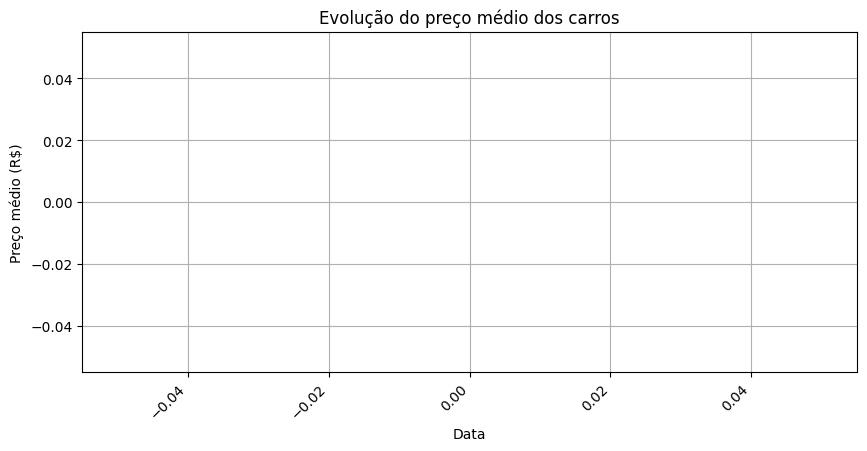

In [16]:
df_tempo['date'] = pd.to_datetime(
    df_tempo['year_of_reference'].astype(str) + '-' +
    df_tempo['month_of_reference'].astype(str).str.zfill(2) + '-01'
)

media_preco = df_tempo.groupby('date')['avg_price_brl'].mean()

plt.figure(figsize=(10,5))
media_preco.plot(marker='o')
plt.title('Evolução do preço médio dos carros')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [17]:
media_preco


Series([], Name: avg_price_brl, dtype: float64)

In [18]:
df_tempo = df[['year_of_reference', 'month_of_reference', 'avg_price_brl']].copy()

df_tempo['year_of_reference'] = pd.to_numeric(df_tempo['year_of_reference'], errors='coerce')
df_tempo['month_of_reference'] = pd.to_numeric(df_tempo['month_of_reference'], errors='coerce')

df_tempo['avg_price_brl'] = (
    df_tempo['avg_price_brl']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)
df_tempo['avg_price_brl'] = pd.to_numeric(df_tempo['avg_price_brl'], errors='coerce')

df_tempo = df_tempo.dropna(subset=['year_of_reference', 'month_of_reference', 'avg_price_brl'])

df_tempo['date'] = pd.to_datetime(
    df_tempo['year_of_reference'].astype(int).astype(str) + '-' +
    df_tempo['month_of_reference'].astype(int).astype(str).str.zfill(2) + '-01'
)

df_tempo.head()

,year_of_reference,month_of_reference,avg_price_brl,date


In [19]:
df_tempo.dtypes

year_of_reference           float64
month_of_reference          float64
avg_price_brl               float64
date                  datetime64[s]
dtype: object

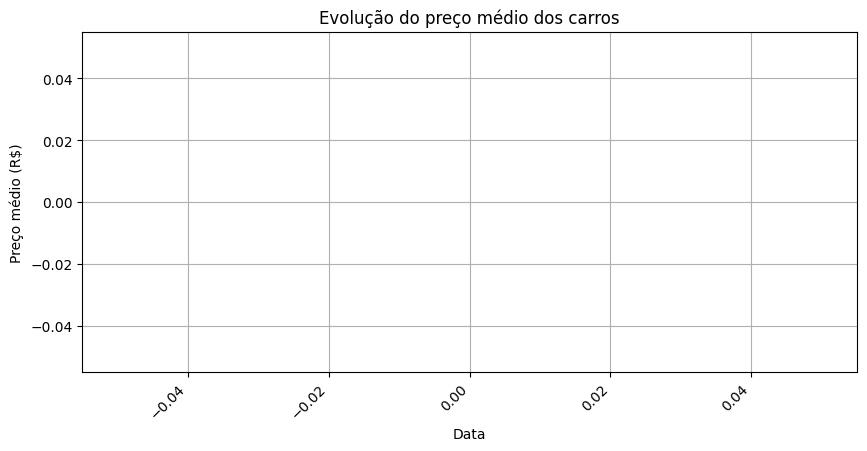

In [20]:
media_preco = df_tempo.groupby('date')['avg_price_brl'].mean()

plt.figure(figsize=(10,5))
media_preco.plot(marker='o')
plt.title('Evolução do preço médio dos carros')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [21]:
df['avg_price_brl'].head(10)

0     9162.0
1     8832.0
2     8388.0
3     8453.0
4    12525.0
5    12020.0
6     9632.0
7    10508.0
8    10167.0
9    12841.0
Name: avg_price_brl, dtype: float64

In [22]:
df['avg_price_brl'].isna().sum()

np.int64(65245)

In [23]:
df['avg_price_brl'].astype(str).head(10)

0     9162.0
1     8832.0
2     8388.0
3     8453.0
4    12525.0
5    12020.0
6     9632.0
7    10508.0
8    10167.0
9    12841.0
Name: avg_price_brl, dtype: str

In [24]:
df_tempo = df[['year_of_reference', 'month_of_reference', 'avg_price_brl']].copy()

df_tempo['year_of_reference'] = pd.to_numeric(df_tempo['year_of_reference'], errors='coerce')
df_tempo['month_of_reference'] = pd.to_numeric(df_tempo['month_of_reference'], errors='coerce')
df_tempo['avg_price_brl'] = pd.to_numeric(df_tempo['avg_price_brl'], errors='coerce')

print(df_tempo.isna().sum())
print(df_tempo.head(10))

year_of_reference      65245
month_of_reference    267542
avg_price_brl          65245
dtype: int64
   year_of_reference  month_of_reference  avg_price_brl
0             2021.0                 NaN         9162.0
1             2021.0                 NaN         8832.0
2             2021.0                 NaN         8388.0
3             2021.0                 NaN         8453.0
4             2021.0                 NaN        12525.0
5             2021.0                 NaN        12020.0
6             2021.0                 NaN         9632.0
7             2021.0                 NaN        10508.0
8             2021.0                 NaN        10167.0
9             2021.0                 NaN        12841.0


In [25]:
df_tempo = df[['year_of_reference', 'month_of_reference', 'avg_price_brl']].copy()

df_tempo['year_of_reference'] = pd.to_numeric(df_tempo['year_of_reference'], errors='coerce')
df_tempo['month_of_reference'] = pd.to_numeric(df_tempo['month_of_reference'], errors='coerce')

df_tempo['avg_price_brl'] = (
    df_tempo['avg_price_brl']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

df_tempo['avg_price_brl'] = pd.to_numeric(df_tempo['avg_price_brl'], errors='coerce')

print(df_tempo.isna().sum())
print(df_tempo.head(10))

year_of_reference      65245
month_of_reference    267542
avg_price_brl          65245
dtype: int64
   year_of_reference  month_of_reference  avg_price_brl
0             2021.0                 NaN        91620.0
1             2021.0                 NaN        88320.0
2             2021.0                 NaN        83880.0
3             2021.0                 NaN        84530.0
4             2021.0                 NaN       125250.0
5             2021.0                 NaN       120200.0
6             2021.0                 NaN        96320.0
7             2021.0                 NaN       105080.0
8             2021.0                 NaN       101670.0
9             2021.0                 NaN       128410.0


In [1]:
df['month_of_reference'].dropna().unique()[:20]

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv('precos_carros_brasil.csv')

C:\Users\Amanda Neumann\AppData\Local\Temp\ipykernel_17636\3642123164.py:3: DtypeWarning: Columns (0: month_of_reference, 1: fipe_code, 2: authentication, 3: brand, 4: model, 5: fuel, 6: gear, 7: engine_size) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('precos_carros_brasil.csv')


In [3]:
df['month_of_reference'].dropna().unique()[:20]

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [5]:
import matplotlib.pyplot as plt

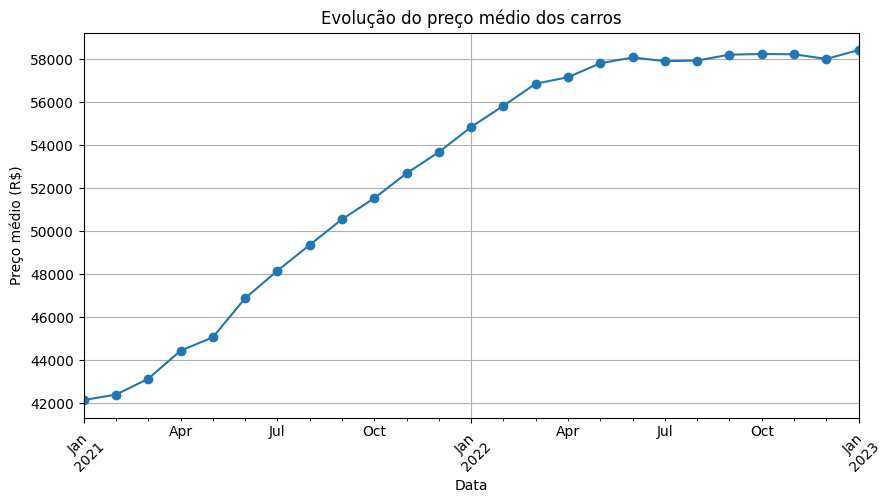

In [6]:
mapa_meses = {
    'january': 1, 'february': 2, 'march': 3, 'april': 4,
    'may': 5, 'june': 6, 'july': 7, 'august': 8,
    'september': 9, 'october': 10, 'november': 11, 'december': 12
}

df_tempo = df[['year_of_reference', 'month_of_reference', 'avg_price_brl']].copy()

# limpar e converter
df_tempo['year_of_reference'] = pd.to_numeric(df_tempo['year_of_reference'], errors='coerce')

df_tempo['month_of_reference'] = (
    df_tempo['month_of_reference']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapa_meses)
)

df_tempo['avg_price_brl'] = pd.to_numeric(df_tempo['avg_price_brl'], errors='coerce')

# remover linhas inválidas
df_tempo = df_tempo.dropna()

# criar data
df_tempo['date'] = pd.to_datetime(
    df_tempo['year_of_reference'].astype(int).astype(str) + '-' +
    df_tempo['month_of_reference'].astype(int).astype(str).str.zfill(2) + '-01'
)

# calcular média
media_preco = df_tempo.groupby('date')['avg_price_brl'].mean().sort_index()

# gráfico
plt.figure(figsize=(10,5))
media_preco.plot(marker='o')
plt.title('Evolução do preço médio dos carros')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

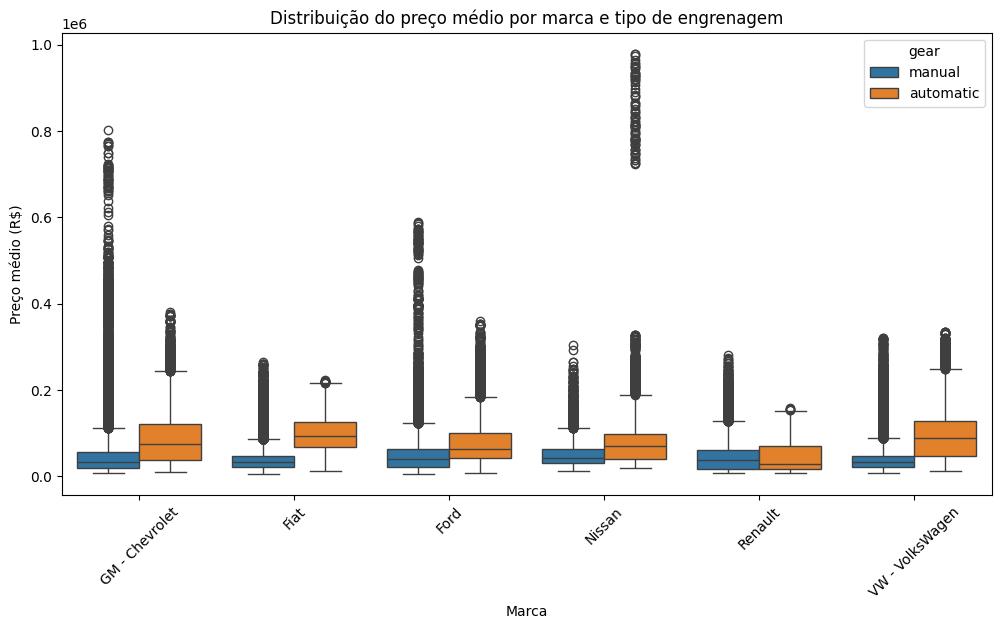

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='brand', y='avg_price_brl', hue='gear')
plt.title('Distribuição do preço médio por marca e tipo de engrenagem')
plt.xlabel('Marca')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.show()

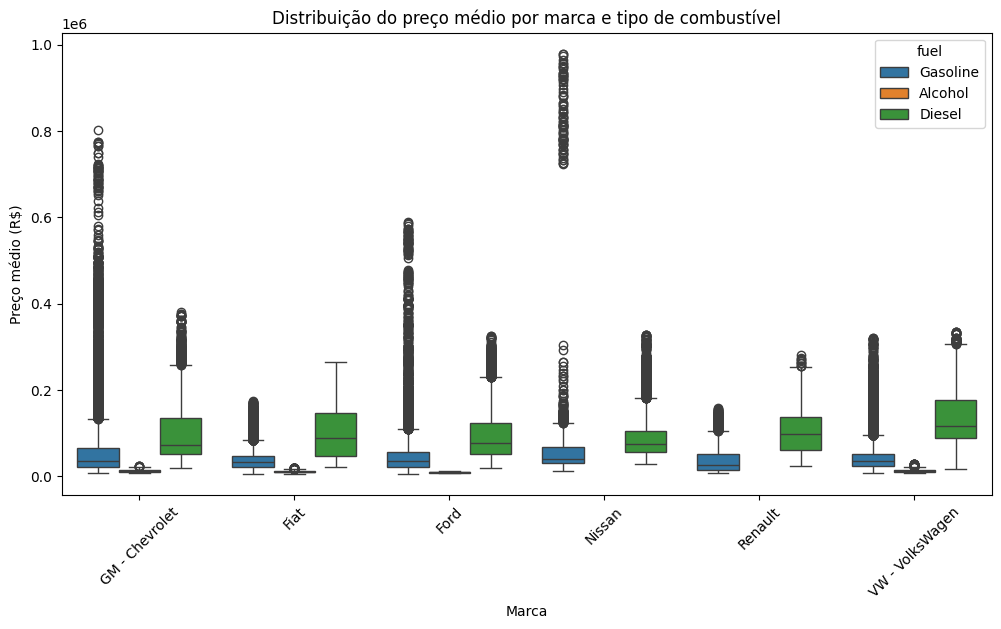

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='brand', y='avg_price_brl', hue='fuel')
plt.title('Distribuição do preço médio por marca e tipo de combustível')
plt.xlabel('Marca')
plt.ylabel('Preço médio (R$)')
plt.xticks(rotation=45)
plt.show()